In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Only errors are logged
os.environ['TF_GPU_ALLOCATOR'] ='cuda_malloc_async'

import numpy as np
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers
from keras import ops

# TF imports related to tf.data preprocessing
from tensorflow import data as tf_data
from tensorflow import image as tf_image
from tensorflow.keras.utils import plot_model

keras.utils.set_random_seed(42)


I0000 00:00:1777018179.311871  263418 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777018180.202208  263418 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
BATCH_SIZE = 32
NUM_CLASSES = 8
EPOCHS = 500
SAMPLE_RATE = 16000
OUT_SEQ_LEN = 72000

In [3]:
keras.backend.clear_session(free_memory=True)
train_ds =tf.keras.utils.image_dataset_from_directory(directory='dataset_mel_img/train',
image_size=(300, 300),
batch_size=BATCH_SIZE)
val_ds =tf.keras.utils.image_dataset_from_directory(directory='dataset_mel_img/val',
image_size=(300, 300),
batch_size=BATCH_SIZE)
test_ds =tf.keras.utils.image_dataset_from_directory(directory='dataset_mel_img/test',
image_size=(300, 300),
batch_size=BATCH_SIZE)

Found 7443 files belonging to 8 classes.
Found 636 files belonging to 8 classes.
Found 636 files belonging to 8 classes.


In [4]:
incv3_5 = keras.applications.InceptionV3(include_top=False,input_shape=(300,300,3))
incv3_5.trainable = False
for layer in incv3_5.layers[-20:]:
    layer.trainable = True
model_5 = keras.Sequential([
  layers.Input(shape=(300,300,3),name='input'),
  layers.Rescaling(1./127.5, offset=-1),
  incv3_5,
  layers.GlobalAveragePooling2D(),
  layers.BatchNormalization(),
  layers.Dense((128),activation='gelu',
                   kernel_regularizer=keras.regularizers.L1L2(l1=1e-5, l2=1e-4),

               ),
  layers.Dropout(0.4),
  layers.Dense((NUM_CLASSES),activation = 'softmax',name='output')
])
model_5.summary()
keras.backend.clear_session(free_memory=True)
model_5.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-5,weight_decay=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,074,280 (84.21 MB)

 Trainable params: 2,202,760 (8.40 MB)

 Non-trainable params: 19,871,520 (75.80 MB)

In [5]:
history_5 = model_5.fit(train_ds,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
          validation_data=val_ds,
        callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        )]        )

Epoch 1/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 35s 96ms/step - loss: 2.5421 - sparse_categorical_accuracy: 0.1881 - val_loss: 1.9127 - val_sparse_categorical_accuracy: 0.3035
Epoch 2/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 2.1150 - sparse_categorical_accuracy: 0.2800 - val_loss: 1.6957 - val_sparse_categorical_accuracy: 0.4072
Epoch 3/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 1.9383 - sparse_categorical_accuracy: 0.3335 - val_loss: 1.5847 - val_sparse_categorical_accuracy: 0.4544
Epoch 4/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 1.8012 - sparse_categorical_accuracy: 0.3775 - val_loss: 1.5052 - val_sparse_categorical_accuracy: 0.4811
Epoch 5/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 1.7052 - sparse_categorical_accuracy: 0.4118 - val_loss: 1.4506 - val_sparse_categorical_accuracy: 0.5000
Epoch 6/500
233/233 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 1.6190 - sparse_categorical_accuracy: 0.4303 - val_loss: 1.4179 - val_sparse_categorical_accuracy

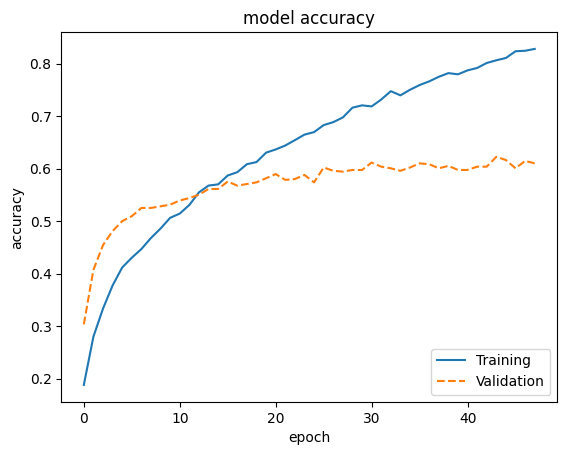

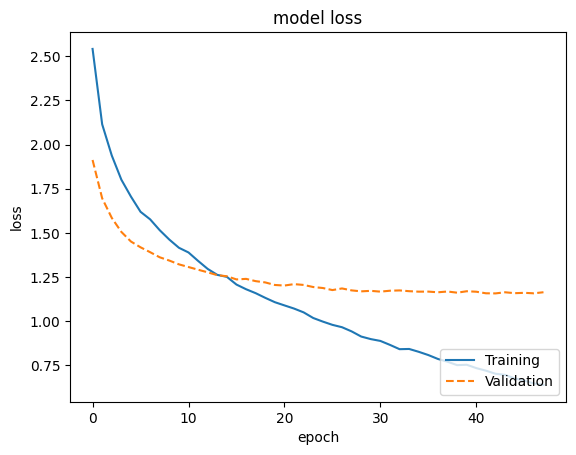

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 1.2132 - sparse_categorical_accuracy: 0.6148


[1.213248610496521, 0.6147798895835876]

In [6]:
plt.plot(history_5.history['sparse_categorical_accuracy'])
plt.plot(history_5.history['val_sparse_categorical_accuracy'],linestyle='--')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()
plt.plot(history_5.history['loss'])
plt.plot(history_5.history['val_loss'],linestyle='--')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()
model_5.evaluate(test_ds)